# Integrated ML–Docking Pipeline for TLR4 Ligand Prioritization

## Purpose

This notebook connects Notebook 01 and Notebook 02 by implementing an integrated
ML-to-structure virtual screening workflow. Machine learning predictions from the
Random Forest model are used to prioritize compounds, which are then validated
through molecular docking into the TLR4–MD2 binding site.

## Workflow

1. Retrieve and curate TLR4 bioactivity data from ChEMBL following the pipeline
   established in Notebook 01
2. Train a Random Forest regressor on ECFP4 Morgan fingerprints to predict pChEMBL potency
3. Select the top 15 highest-predicted-activity compounds as virtual screening candidates
4. Dock each candidate into the TLR4–MD2 binding site using the AutoDock Vina
   pipeline established in Notebook 02
5. Compare ML-predicted potency against Vina binding affinity scores
6. Identify consensus hits — compounds ranked highly by both approaches

## Scientific Rationale

Machine learning and molecular docking capture complementary aspects of
ligand–receptor interaction. ML captures statistical patterns across large
bioactivity datasets while docking provides structural and energetic validation
at the binding site. Compounds ranked highly by both methods represent the most
confident candidates to pass to experimental collaborators, reducing the risk
of pursuing false positives from either approach alone.

## Target

- Receptor: Human TLR4–MD2 complex (PDB: 3FXI)
- Binding site: MD-2 hydrophobic pocket (Chain C geometric center)
- Activity endpoint: pChEMBL value (IC50/EC50/Ki, −log10 molar units)
- Docking grid: center x=29.39, y=1.30, z=20.49 — box 24×24×24 Å

## Step 1: Install Dependencies

In [1]:
!pip install chembl-webresource-client rdkit shap -q

!pip install vina -q
!apt-get install -y autodock-vina openbabel -q

print("All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 96.2 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libboost-filesystem1.74.0 libboost-iostreams1.74.0
  libboost-program-options1.74.0 libboost-thread1.74.0 libinchi1 libmaeparser1
  libopenbabel7
Suggested packages:
  autodock autogrid
The following NEW packages will be installed:
  autodock-vina libboost-filesystem1.74.0 libboost-iostreams1.74.0
  libboost-program-options1.74.0 libboost-thread1.74.0 libinchi1 libmaeparser1
  libopenbabel7 openbabel
0 upgraded, 9 newly installed, 0 to remove and 5 not upgraded.
Need t

## Step 2: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import subprocess
import os
import warnings
warnings.filterwarnings('ignore')

from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, AllChem, Descriptors
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Imports complete.")

Imports complete.


## Step 3: Retrieve and Curate TLR4 Bioactivity Data (ChEMBL)

Condensed from Notebook 01. Retrieves human TLR4 bioactivity data, curates to valid pChEMBL values,
aggregates per molecule, and generates ECFP4 fingerprints.

In [3]:
# 3.1 Target identification
target = new_client.target
targets = target.search("TLR4")
targets_df = pd.DataFrame(targets)

human_tlr4 = targets_df[
    (targets_df['organism'] == "Homo sapiens") &
    (targets_df['target_type'] == "SINGLE PROTEIN") &
    (targets_df['pref_name'] == "Toll-like receptor 4")
]
tlr4_chembl_id = human_tlr4.iloc[0]['target_chembl_id']
print(f"TLR4 ChEMBL ID: {tlr4_chembl_id}")

# 3.2 Bioactivity retrieval
activity = new_client.activity
activities = activity.filter(
    target_chembl_id=tlr4_chembl_id,
    standard_type__in=['IC50', 'EC50', 'Ki', 'Potency']
)
df_raw = pd.DataFrame.from_records(activities)

# 3.3 Curation
df_curated = df_raw.copy()
df_curated = df_curated[df_curated['standard_value'].notna()]
df_curated = df_curated[df_curated['standard_units'] == 'nM']
df_curated = df_curated[df_curated['pchembl_value'].notna()]
df_curated['pchembl_value'] = pd.to_numeric(df_curated['pchembl_value'], errors='coerce')
df_curated['standard_value'] = pd.to_numeric(df_curated['standard_value'], errors='coerce')
df_curated = df_curated.dropna(subset=['pchembl_value', 'canonical_smiles'])

# 3.4 Molecule-level aggregation (median pChEMBL)
df_model = df_curated[['molecule_chembl_id', 'canonical_smiles', 'standard_type', 'pchembl_value']].copy()
df_model_agg = (
    df_model
    .groupby(['molecule_chembl_id', 'canonical_smiles', 'standard_type'], as_index=False)
    .agg({'pchembl_value': 'median'})
)

print(f"Curated dataset: {df_model_agg.shape[0]} molecule-endpoint records")
print(df_model_agg['standard_type'].value_counts())

TLR4 ChEMBL ID: CHEMBL5255
Curated dataset: 190 molecule-endpoint records
standard_type
IC50    122
EC50     68
Name: count, dtype: int64


## Step 4: Generate ECFP4 Molecular Fingerprints

Morgan fingerprints (radius=2, 2048 bits) are generated as the feature matrix for the RF model.
This is identical to the featurization in Notebook 01.

In [4]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

df_model_agg['fingerprint'] = df_model_agg['canonical_smiles'].apply(smiles_to_ecfp)
df_ml = df_model_agg.dropna(subset=['fingerprint']).copy()

X = np.stack(df_ml['fingerprint'].values)
y = df_ml['pchembl_value'].values

print(f"Feature matrix: {X.shape}")
print(f"Target vector:  {y.shape}")
print(f"pChEMBL range:  {y.min():.2f} – {y.max():.2f}")

Feature matrix: (190, 2048)
Target vector:  (190,)
pChEMBL range:  4.19 – 10.39


## Step 5: Train Random Forest Regressor

Trained on 80% of data, evaluated on 20% hold-out set.
The trained model is then applied to all compounds to generate ranked predictions.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_test = rf_model.predict(X_test)
r2   = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

print(f"RF Model Performance (hold-out test set)")
print(f"  R²   : {r2:.3f}")
print(f"  RMSE : {rmse:.3f}")
print(f"  MAE  : {mae:.3f}")

RF Model Performance (hold-out test set)
  R²   : 0.727
  RMSE : 0.466
  MAE  : 0.308


## Step 6: Select Top 15 Virtual Screening Candidates

The trained RF model predicts pChEMBL values for all compounds in the dataset.
The top 15 highest-predicted-activity compounds are selected as docking candidates.

These represent the molecules that the ML model considers most likely to be potent TLR4 modulators,
and they will now be structurally validated by molecular docking.

In [6]:
# Predict pChEMBL for all molecules
df_ml = df_ml.copy()
df_ml['predicted_pchembl'] = rf_model.predict(X)

# Rank by predicted activity (descending)
df_top = (
    df_ml
    .sort_values('predicted_pchembl', ascending=False)
    .drop_duplicates(subset='molecule_chembl_id')
    .head(15)
    .reset_index(drop=True)
)

df_top['rank_ml'] = range(1, len(df_top) + 1)

print("Top 15 ML-predicted TLR4 candidates:")
print(df_top[['rank_ml', 'molecule_chembl_id', 'predicted_pchembl', 'pchembl_value', 'standard_type']].to_string(index=False))

Top 15 ML-predicted TLR4 candidates:
 rank_ml molecule_chembl_id  predicted_pchembl  pchembl_value standard_type
       1      CHEMBL5423611           9.456663          9.645          EC50
       2      CHEMBL3354639           9.422994          9.400          EC50
       3      CHEMBL3354640           9.422994         10.100          EC50
       4      CHEMBL5407900           9.400280          9.485          EC50
       5       CHEMBL501231           9.363555          8.280          IC50
       6       CHEMBL507938           9.363555         10.385          EC50
       7      CHEMBL5407887           8.906456          9.100          EC50
       8       CHEMBL505526           8.600803          8.620          IC50
       9      CHEMBL5433813           8.580703          8.660          EC50
      10       CHEMBL501259           8.537831          8.820          IC50
      11      CHEMBL5417929           8.411331          8.700          EC50
      12      CHEMBL5428754           8.328323     

## Step 7: Upload TLR4–MD2 Receptor Structure

Upload the receptor PDBQT file prepared in Notebook 02 (`receptor.pdbqt`).

If you have not yet run Notebook 02, download PDB 3FXI from https://www.rcsb.org,
run steps 1–10 of Notebook 02 to generate `receptor.pdbqt`, then upload it here.

**Docking grid parameters (from Notebook 02):**
- Center: x=29.39, y=1.30, z=20.49 (MD-2 geometric center)
- Box size: 24 x 24 x 24 Angstrom

In [7]:
from google.colab import files

print("Please upload receptor.pdbqt (generated in Notebook 1):")
uploaded = files.upload()

# Verify upload
if 'receptor.pdbqt' in uploaded:
    print("receptor.pdbqt uploaded successfully.")
else:
    print("Warning: expected 'receptor.pdbqt'. Rename your file if needed.")

# Docking grid (MD-2 pocket center from Notebook 1)
CENTER_X = 29.39
CENTER_Y = 1.30
CENTER_Z = 20.49
BOX_SIZE  = 24

Please upload receptor.pdbqt (generated in Notebook 1):


Saving receptor.pdbqt to receptor.pdbqt
receptor.pdbqt uploaded successfully.


## Step 8: Ligand Preparation Function

A utility function to convert each SMILES string into a docking-ready PDBQT file.

**Pipeline per ligand:**
SMILES → 3D structure (Open Babel, --gen3d --minimize) → PDBQT (atom types + partial charges)

In [8]:
def prepare_ligand_pdbqt(smiles, name, timeout=45):
    # --minimize REMOVED: it hangs on large lipid-like TLR4 ligands
    # --gen3d alone is sufficient for docking geometry
    # 45s hard timeout prevents blocking on any single compound
    smi_file   = f"{name}.smi"
    pdb_file   = f"{name}.pdb"
    pdbqt_file = f"{name}.pdbqt"

    with open(smi_file, "w") as f:
        f.write(smiles)

    try:
        subprocess.run(
            ["obabel", smi_file, "-O", pdb_file, "--gen3d"],
            capture_output=True, text=True, timeout=timeout
        )
    except subprocess.TimeoutExpired:
        print("TIMEOUT (3D gen)", end=" ")
        return None

    if not os.path.exists(pdb_file) or os.path.getsize(pdb_file) == 0:
        return None

    try:
        subprocess.run(
            ["obabel", pdb_file, "-O", pdbqt_file],
            capture_output=True, text=True, timeout=timeout
        )
    except subprocess.TimeoutExpired:
        print("TIMEOUT (pdbqt)", end=" ")
        return None

    if not os.path.exists(pdbqt_file) or os.path.getsize(pdbqt_file) == 0:
        return None

    return pdbqt_file

print("prepare_ligand_pdbqt() ready  (no --minimize, 45s timeout)")

prepare_ligand_pdbqt() ready  (no --minimize, 45s timeout)


## Step 9: Docking Function

Runs AutoDock Vina for a single ligand and parses the best binding affinity score (kcal/mol).
The same docking parameters as Notebook 02 are used to ensure consistency.

In [9]:
def run_docking(ligand_pdbqt, name, timeout=90):
    # exhaustiveness 8 → 4, num_modes 5 → 3
    # 90s hard timeout kills any stalled Vina process
    out_file = f"{name}_docked.pdbqt"

    try:
        result = subprocess.run([
            "vina",
            "--receptor", "receptor.pdbqt",
            "--ligand",   ligand_pdbqt,
            "--center_x", str(CENTER_X),
            "--center_y", str(CENTER_Y),
            "--center_z", str(CENTER_Z),
            "--size_x",   str(BOX_SIZE),
            "--size_y",   str(BOX_SIZE),
            "--size_z",   str(BOX_SIZE),
            "--exhaustiveness", "4",
            "--num_modes", "3",
            "--out", out_file
        ], capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print("TIMEOUT (vina)", end=" ")
        return None

    if os.path.exists(out_file):
        with open(out_file) as f:
            for line in f:
                if "VINA RESULT" in line:
                    try:
                        return float(line.split()[3])
                    except (IndexError, ValueError):
                        pass

    for line in result.stdout.split("\n"):
        parts = line.split()
        if len(parts) >= 4 and parts[0] == "1":
            try:
                return float(parts[1])
            except ValueError:
                pass

    return None

print("run_docking() ready  (exhaustiveness=4, 3 modes, 90s timeout)")

run_docking() ready  (exhaustiveness=4, 3 modes, 90s timeout)


## Step 9b: Filter Candidates to Drug-Like Chemical Space

Before docking, compounds are filtered using two physicochemical criteria:

- **Molecular Weight < 600 Da** — removes large lipid-like molecules
- **Rotatable Bonds ≤ 10** — removes highly flexible compounds

ChEMBL TLR4 data is dominated by LPS analogs and lipid A mimetics — large, flexible molecules
that are biologically relevant but cause AutoDock Vina to time out due to their high rotatable
bond count. Filtering to drug-like compounds is also scientifically motivated: small-molecule
TLR4 modulators are the primary target for drug development, as large lipid conjugates are
difficult to synthesize and formulate as therapeutics.

In [10]:
from rdkit.Chem import Descriptors

def get_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None, None
    return (
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumRotatableBonds(mol)
    )

df_ml[['MW', 'LogP', 'RotBonds']] = df_ml['canonical_smiles'].apply(
    lambda s: pd.Series(get_props(s))
)

# Filter to drug-like compounds: MW < 600, RotBonds <= 10
# These dock reliably within the timeout
df_ml_filtered = df_ml[
    (df_ml['MW'] < 600) &
    (df_ml['RotBonds'] <= 10)
].copy()

print(f"Before filter : {len(df_ml)} compounds")
print(f"After filter  : {len(df_ml_filtered)} drug-like compounds")
print(f"Removed       : {len(df_ml) - len(df_ml_filtered)} large/flexible molecules")

# Re-select top 15 from filtered set
df_top = (
    df_ml_filtered
    .sort_values('predicted_pchembl', ascending=False)
    .drop_duplicates(subset='molecule_chembl_id')
    .head(15)
    .reset_index(drop=True)
)
df_top['rank_ml'] = range(1, len(df_top) + 1)

print(f"\nTop 15 drug-like candidates for docking:")
print(f"  pChEMBL range : {df_top['predicted_pchembl'].min():.2f} – {df_top['predicted_pchembl'].max():.2f}")
print(f"  MW range      : {df_top['MW'].min():.0f} – {df_top['MW'].max():.0f} Da")
print(f"  RotBonds range: {df_top['RotBonds'].min():.0f} – {df_top['RotBonds'].max():.0f}")
print(df_top[['rank_ml','molecule_chembl_id','predicted_pchembl','MW','RotBonds']].to_string(index=False))

Before filter : 190 compounds
After filter  : 138 drug-like compounds
Removed       : 52 large/flexible molecules

Top 15 drug-like candidates for docking:
  pChEMBL range : 6.11 – 7.01
  MW range      : 198 – 497 Da
  RotBonds range: 1 – 8
 rank_ml molecule_chembl_id  predicted_pchembl      MW  RotBonds
       1      CHEMBL5174883           7.007881 228.244       1.0
       2       CHEMBL375048           6.472150 375.849       5.0
       3       CHEMBL224563           6.461983 361.822       5.0
       4      CHEMBL5422246           6.443817 198.218       3.0
       5       CHEMBL224199           6.317083 347.795       5.0
       6       CHEMBL225157           6.281983 361.822       5.0
       7       CHEMBL426184           6.281983 361.822       5.0
       8      CHEMBL4643502           6.276100 336.439       2.0
       9      CHEMBL3261034           6.275533 459.586       4.0
      10      CHEMBL5186900           6.248467 226.235       3.0
      11      CHEMBL4450337           6.2479

## Step 10: Virtual Screening — Dock All 15 Candidates

Each of the 15 ML-selected candidates is:
1. Converted from SMILES to a 3D structure
2. Prepared as a PDBQT ligand file
3. Docked into the TLR4–MD2 binding site
4. Scored for binding affinity (kcal/mol)

This loop is the structural validation step of the ML–docking design cycle.

In [11]:
import time

results = []

for i, row in df_top.iterrows():
    cid    = row["molecule_chembl_id"]
    smiles = row["canonical_smiles"]
    pred   = row["predicted_pchembl"]
    obs    = row["pchembl_value"]
    name   = f"lig_{i+1:02d}_{cid}"

    t0 = time.time()
    print(f"[{i+1:2d}/15] {cid}  pred={pred:.2f} ...", end=" ", flush=True)

    pdbqt = prepare_ligand_pdbqt(smiles, name)
    if pdbqt is None:
        print(f"PREP FAILED  ({time.time()-t0:.1f}s)")
        results.append({"rank_ml": i+1, "molecule_chembl_id": cid,
                         "predicted_pchembl": pred, "observed_pchembl": obs,
                         "docking_score": None, "status": "prep_failed"})
        continue

    score = run_docking(pdbqt, name)
    elapsed = time.time() - t0

    if score is None:
        print(f"DOCKING FAILED  ({elapsed:.1f}s)")
        results.append({"rank_ml": i+1, "molecule_chembl_id": cid,
                         "predicted_pchembl": pred, "observed_pchembl": obs,
                         "docking_score": None, "status": "docking_failed"})
        continue

    print(f"score = {score:.2f} kcal/mol  ({elapsed:.1f}s)")
    results.append({"rank_ml": i+1, "molecule_chembl_id": cid,
                     "predicted_pchembl": pred, "observed_pchembl": obs,
                     "docking_score": score, "status": "ok"})

df_results = pd.DataFrame(results)
n_ok = (df_results["status"] == "ok").sum()
print(f"\nDone. {n_ok}/15 docked successfully.")
df_results

[ 1/15] CHEMBL5174883  pred=7.01 ... score = -5.22 kcal/mol  (11.0s)
[ 2/15] CHEMBL375048  pred=6.47 ... score = -7.37 kcal/mol  (26.1s)
[ 3/15] CHEMBL224563  pred=6.46 ... score = -7.20 kcal/mol  (23.2s)
[ 4/15] CHEMBL5422246  pred=6.44 ... score = -6.22 kcal/mol  (11.1s)
[ 5/15] CHEMBL224199  pred=6.32 ... score = -6.96 kcal/mol  (23.5s)
[ 6/15] CHEMBL225157  pred=6.28 ... score = -7.04 kcal/mol  (24.5s)
[ 7/15] CHEMBL426184  pred=6.28 ... score = -6.96 kcal/mol  (23.2s)
[ 8/15] CHEMBL4643502  pred=6.28 ... score = -9.21 kcal/mol  (15.9s)
[ 9/15] CHEMBL3261034  pred=6.28 ... score = -9.12 kcal/mol  (31.8s)
[10/15] CHEMBL5186900  pred=6.25 ... score = -7.91 kcal/mol  (10.4s)
[11/15] CHEMBL4450337  pred=6.25 ... score = -6.92 kcal/mol  (35.1s)
[12/15] CHEMBL3261035  pred=6.17 ... score = -8.95 kcal/mol  (40.3s)
[13/15] CHEMBL3261031  pred=6.16 ... score = -8.74 kcal/mol  (29.4s)
[14/15] CHEMBL3261032  pred=6.11 ... score = -8.22 kcal/mol  (35.5s)
[15/15] CHEMBL4538376  pred=6.11 ... sc

,rank_ml,molecule_chembl_id,predicted_pchembl,observed_pchembl,docking_score,status
0,1,CHEMBL5174883,7.007881,7.955,-5.216,ok
1,2,CHEMBL375048,6.472150,6.620,-7.367,ok
2,3,CHEMBL224563,6.461983,6.800,-7.202,ok
3,4,CHEMBL5422246,6.443817,6.370,-6.223,ok
4,5,CHEMBL224199,6.317083,6.960,-6.959,ok
5,6,CHEMBL225157,6.281983,6.170,-7.041,ok
6,7,CHEMBL426184,6.281983,7.945,-6.963,ok
7,8,CHEMBL4643502,6.276100,6.600,-9.208,ok
8,9,CHEMBL3261034,6.275533,6.410,-9.125,ok
9,10,CHEMBL5186900,6.248467,6.550,-7.914,ok


## Step 11: Results Table

Summary of ML predictions vs. docking scores for all 15 candidates.

A more negative docking score indicates stronger predicted binding affinity.
A higher pChEMBL value indicates higher predicted potency from the ML model.

Consensus hits compounds with both high predicted pChEMBL AND strongly negative docking scores are the most confident design hypotheses.

In [12]:
df_docked = df_results.dropna(subset=['docking_score']).copy()

# Add docking rank (most negative = rank 1)
df_docked['rank_docking'] = df_docked['docking_score'].rank(ascending=True).astype(int)

# Consensus score: average of ML rank and docking rank
df_docked['consensus_rank'] = ((df_docked['rank_ml'] + df_docked['rank_docking']) / 2).round(1)
df_docked = df_docked.sort_values('consensus_rank')

display_cols = [
    'rank_ml', 'rank_docking', 'consensus_rank',
    'molecule_chembl_id', 'predicted_pchembl',
    'observed_pchembl', 'docking_score'
]

print("=" * 80)
print("ML → DOCKING SCREENING RESULTS")
print("=" * 80)
print(df_docked[display_cols].to_string(index=False))
print()
print("Top 5 Consensus Hits (best combined ML + docking ranking):")
print(df_docked[display_cols].head(5).to_string(index=False))

ML → DOCKING SCREENING RESULTS
 rank_ml  rank_docking  consensus_rank molecule_chembl_id  predicted_pchembl  observed_pchembl  docking_score
       8             1             4.5      CHEMBL4643502           6.276100             6.600         -9.208
       2             8             5.0       CHEMBL375048           6.472150             6.620         -7.367
       9             2             5.5      CHEMBL3261034           6.275533             6.410         -9.125
       3             9             6.0       CHEMBL224563           6.461983             6.800         -7.202
      12             3             7.5      CHEMBL3261035           6.168133             6.200         -8.947
       1            15             8.0      CHEMBL5174883           7.007881             7.955         -5.216
       6            10             8.0       CHEMBL225157           6.281983             6.170         -7.041
       5            12             8.5       CHEMBL224199           6.317083             

## Step 12: Correlation Analysis — ML Prediction vs. Docking Score

A scatter plot of predicted pChEMBL (ML) vs. docking binding affinity (Vina) for all docked compounds.

**Expected trend:** compounds with higher predicted pChEMBL should show more negative docking scores,
confirming structural plausibility of ML predictions.

**Divergences** are scientifically informative as they indicate cases where ML detects bioactivity
patterns not captured by static docking (e.g., metabolic activation, off-target effects) or
where docking reveals geometric incompatibility missed by fingerprint-based ML.

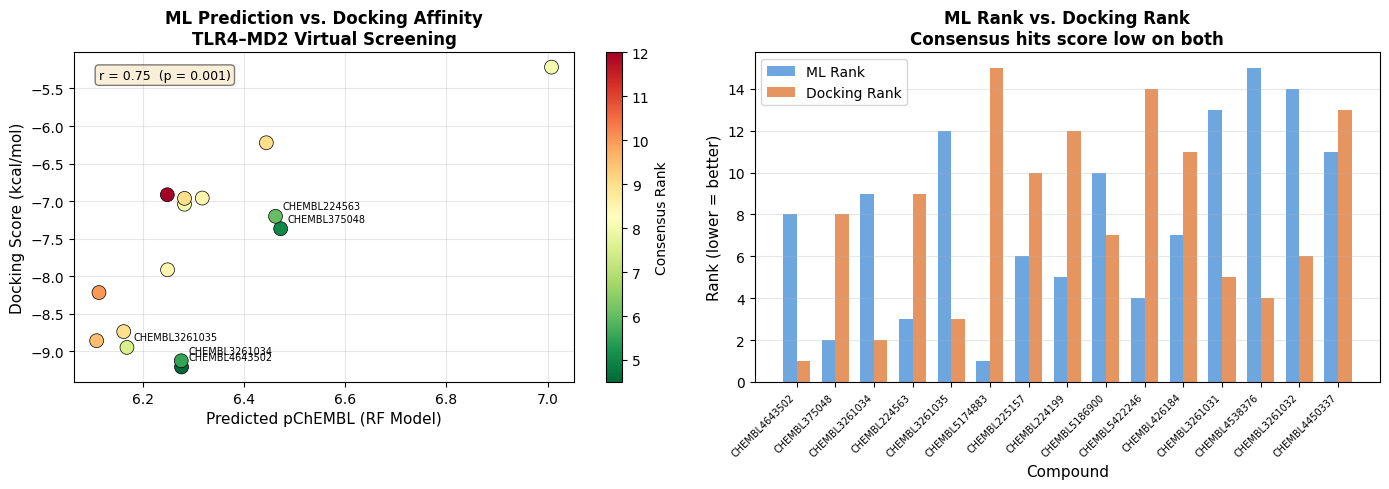

Figure saved as ml_docking_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter — predicted pChEMBL vs docking score
ax1 = axes[0]
sc = ax1.scatter(
    df_docked['predicted_pchembl'],
    df_docked['docking_score'],
    c=df_docked['consensus_rank'],
    cmap='RdYlGn_r',
    s=100,
    edgecolors='black',
    linewidths=0.5,
    zorder=3
)

# Annotate top 5 consensus hits
for _, row in df_docked.head(5).iterrows():
    ax1.annotate(
        row['molecule_chembl_id'],
        (row['predicted_pchembl'], row['docking_score']),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.colorbar(sc, ax=ax1, label='Consensus Rank')
ax1.set_xlabel('Predicted pChEMBL (RF Model)', fontsize=11)
ax1.set_ylabel('Docking Score (kcal/mol)', fontsize=11)
ax1.set_title('ML Prediction vs. Docking Affinity\nTLR4–MD2 Virtual Screening', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add Pearson correlation
from scipy.stats import pearsonr
r, p = pearsonr(df_docked['predicted_pchembl'], df_docked['docking_score'])
ax1.text(0.05, 0.95, f'r = {r:.2f}  (p = {p:.3f})',
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Dual-rank bar chart
ax2 = axes[1]
x = np.arange(len(df_docked))
width = 0.35

bars1 = ax2.bar(x - width/2, df_docked['rank_ml'],       width, label='ML Rank',      color='#4a90d9', alpha=0.8)
bars2 = ax2.bar(x + width/2, df_docked['rank_docking'],  width, label='Docking Rank', color='#e07b39', alpha=0.8)

ax2.set_xlabel('Compound', fontsize=11)
ax2.set_ylabel('Rank (lower = better)', fontsize=11)
ax2.set_title('ML Rank vs. Docking Rank\nConsensus hits score low on both', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_docked['molecule_chembl_id'], rotation=45, ha='right', fontsize=7)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ml_docking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as ml_docking_comparison.png")

## Step 13: Consensus Hit Analysis

The top 3 consensus hits compounds that score well on both ML prediction and docking
are the primary design hypotheses to report to experimental collaborators.

Computational predictions are synthesized into actionable hypotheses that guide
experimental testing and compound optimization.

TOP 3 CONSENSUS HITS — TLR4 VIRTUAL SCREENING
Compound  : CHEMBL4643502
ML pChEMBL: 6.28
Docking   : -9.21 kcal/mol
Observed  : 6.60
----------------------------------------
Compound  : CHEMBL375048
ML pChEMBL: 6.47
Docking   : -7.37 kcal/mol
Observed  : 6.62
----------------------------------------
Compound  : CHEMBL3261034
ML pChEMBL: 6.28
Docking   : -9.12 kcal/mol
Observed  : 6.41
----------------------------------------


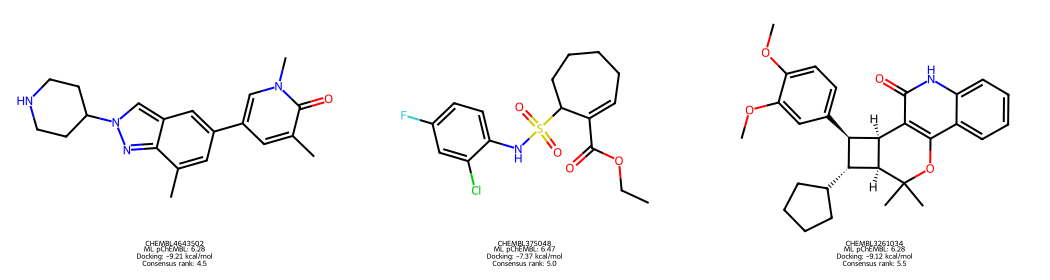


Structures saved as consensus_hits.png


In [14]:
from rdkit.Chem import Draw
from IPython.display import display

# Merge canonical_smiles back in from df_top
df_docked = df_docked.merge(
    df_top[['molecule_chembl_id', 'canonical_smiles']],
    on='molecule_chembl_id',
    how='left'
)

top_hits = df_docked.head(3)

print("TOP 3 CONSENSUS HITS — TLR4 VIRTUAL SCREENING")
print("=" * 60)

mols = []
legends = []

for _, row in top_hits.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mols.append(mol)
        legends.append(
            f"{row['molecule_chembl_id']}\n"
            f"ML pChEMBL: {row['predicted_pchembl']:.2f}\n"
            f"Docking: {row['docking_score']:.2f} kcal/mol\n"
            f"Consensus rank: {row['consensus_rank']}"
        )
    print(f"Compound  : {row['molecule_chembl_id']}")
    print(f"ML pChEMBL: {row['predicted_pchembl']:.2f}")
    print(f"Docking   : {row['docking_score']:.2f} kcal/mol")
    print(f"Observed  : {row['observed_pchembl']:.2f}")
    print("-" * 40)

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(350, 280), legends=legends, returnPNG=False)
    img.save('consensus_hits.png')
    display(img)
    print("\nStructures saved as consensus_hits.png")

## Step 14: Scientific Discussion

### Interpreting the Results

**Agreement between ML and docking** (high predicted pChEMBL + strongly negative docking score)
indicates that a compound is likely active both statistically (based on structural similarity to
known TLR4 actives in ChEMBL) and structurally (favorable geometric fit and energetics in the
MD-2 binding pocket). These are the highest-confidence design hypotheses.

**Disagreements** are equally informative:
- High ML prediction, weak docking: the compound may be active through a binding mode not
  captured by the MD-2 pocket model (e.g., TLR4 ectodomain interactions), or may require
  metabolic activation.
- Weak ML prediction, strong docking: structurally novel compound not represented in training data
  potentially interesting for scaffold diversification.

### Limitations

- Docking scores are estimates; they do not account for solvation, entropy, or protein flexibility.
- The RF model is trained on ChEMBL data which mixes assay formats; prediction uncertainty is
  higher for chemically novel compounds.
- MD-2 pocket geometry was taken from a static crystal structure; induced-fit effects are not modeled.

### Future Directions

- Molecular dynamics (MD) simulations to assess stability of docked complexes over time
- Expand dataset with PubChem BioAssay TLR4 data and retrain models
- Apply generative models to propose structural modifications to top hits
- Pass consensus hits to experimental collaborators for in vitro TLR4 stimulation assays